# Joint Optimization And Hyperparameter Tuning (Fashion-MNIST)

This notebook is the formal tuning notebook for the Fashion-MNIST joint model.


## Tuning Principle

The current evidence shows that some joint configurations can fit the training
set very well while still generalizing worse than the separate baseline.
Therefore the tuning protocol must explicitly distinguish:

- optimization quality,
- validation performance,
- generalization gap,
- representation sparsity,
- final test performance.

This notebook follows the rule below:

1. Use `train` only for fitting.
2. Use `val` for hyperparameter selection.
3. Do not use `test` to choose hyperparameters.
4. Only after a final joint configuration is selected should `test` be
   inspected for reporting in the final results notebook.


## Protocol Overview

The tuning is divided into five stages.

### Stage 0
Run the default joint model once and inspect optimization diagnostics.

### Stage 1
Coarse search over the coupling and hinge weights `rho` and `eta`.

### Stage 1B
Re-check the best Stage 1 candidates over multiple random seeds.
This guards against picking a lucky single-seed configuration.

### Stage 2
Tune representation capacity and sparsity with `dictionary_size` and `mu`.
Since the current joint model can overfit while becoming almost non-sparse,
this stage is especially important.

### Stage 3
Tune classifier regularization `gamma` and, if needed, optimization budget
`max_iter`.

### Stage 4
Run the final selected joint configuration over multiple seeds and summarize the
validation mean/std before transferring the final joint configuration into the
results notebook.

### Selection Rule
Use the following ranking logic:

1. highest mean validation accuracy,
2. lower validation standard deviation,
3. smaller mean train-validation accuracy gap,
4. stronger code sparsity when accuracy is essentially tied,
5. lower validation reconstruction error as a final tie-breaker.


In [1]:
from copy import deepcopy
from itertools import product
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import math
import numpy as np
import matplotlib.pyplot as plt

from src.config import default_hyperparams, fashion_task_suite
from src.data import load_task
from src.init import initialize_params
from src.solver import fit_joint_pg
from src.experiments import (
    joint_dictionary_svm_diagnostic,
    format_dictionary_svm_diagnostic,
)
from src.metrics import (
    summarize_joint_result,
    evaluate_joint_model,
    joint_component_scale_report,
    format_joint_scale_report,
    format_training_diagnostic_trajectory,
    format_inferred_monitor_trajectory,
    joint_code_distribution_report,
    format_code_distribution_report,
    overfitting_diagnostic_summary,
    format_overfitting_diagnostic,
)


In [8]:
task_cfg = fashion_task_suite()[0]
base_hyper = default_hyperparams()
base_hyper.mu = 0.3
base_hyper.gamma = 0.1
base_hyper.max_iter = 100
base_hyper.eta = 10
base_hyper.rho = 10
base_hyper.dictionary_size = 48
base_hyper.init_code_scale = 5e-3
base_hyper.init_classifier_scale = 5e-3
base_hyper.code_correction_every = 20
base_hyper.code_correction_max_iter = 50
base_hyper.code_correction_blend = 0.05
base_hyper.code_correction_update_u = True

X_train, y_train, X_val, y_val, X_test, y_test = load_task(task_cfg)

print('task:', task_cfg.dataset, task_cfg.name)
print('train shape:', X_train.shape, y_train.shape)
print('val shape:', X_val.shape, y_val.shape)
print('test shape:', X_test.shape, y_test.shape)
print('base hyperparameters:', base_hyper)


task: fashion_mnist T-shirt vs Shirt
train shape: (784, 1000) (1000,)
val shape: (784, 200) (200,)
test shape: (784, 400) (400,)
base hyperparameters: HyperParams(dictionary_size=48, mu=0.3, rho=10, gamma=0.1, eta=10, init_code_scale=0.005, init_classifier_scale=0.005, initial_step=1.0, backtracking_shrink=0.5, backtracking_min_step=1e-08, max_iter=100, tol=1e-05, random_state=7, code_correction_every=20, code_correction_max_iter=50, code_correction_blend=0.05, code_correction_update_u=True)


## Code-Correction Experiment

This notebook now enables periodic code correction for the default diagnostic run. Every `code_correction_every` iterations, the solver fixes the current dictionary `D`, re-infers `C_train` using the same sparse-coding problem used at validation/test time, softly blends the optimized codes toward the inferred codes, and then updates `u` to match the new margin residual.

Purpose: reduce the mismatch between directly optimized training codes and fixed-D inferred validation/test codes. This is an algorithmic diagnostic variant, not the original pure joint PG baseline.


## Helper Functions

These helpers keep the protocol consistent across all stages.


In [3]:
def train_joint_once(hyper, seed=None, *, evaluate_test=False, monitor=False):
    local_hyper = deepcopy(hyper)
    if seed is not None:
        local_hyper.random_state = seed

    init_params = initialize_params(
        X_train,
        y_train,
        local_hyper.dictionary_size,
        seed=local_hyper.random_state,
        code_scale=local_hyper.init_code_scale,
        classifier_scale=local_hyper.init_classifier_scale,
    )
    monitor_kwargs = {}
    if monitor:
        monitor_kwargs = {
            'monitor_data': {
                'train_inferred': (X_train, y_train),
                'val': (X_val, y_val),
                'test': (X_test, y_test),
            },
            'monitor_every': 10,
            'monitor_code_max_iter': 50,
        }
    result = fit_joint_pg(X_train, y_train, local_hyper, init_params, **monitor_kwargs)
    train_metrics = summarize_joint_result(result, X_train, y_train)
    val_metrics = evaluate_joint_model(X_val, y_val, result['params'], local_hyper)
    payload = {
        'hyper': local_hyper,
        'result': result,
        'train_metrics': train_metrics,
        'val_metrics': val_metrics,
        'scale_report': joint_component_scale_report(result),
    }
    if evaluate_test:
        payload['test_metrics'] = evaluate_joint_model(X_test, y_test, result['params'], local_hyper)
    return payload


def scan_joint_grid(base_hyper, param_grid, seeds, *, evaluate_test=False):
    rows = []
    keys = list(param_grid.keys())
    values_list = [param_grid[key] for key in keys]

    for combo in product(*values_list):
        combo_values = dict(zip(keys, combo))
        for seed in seeds:
            local_hyper = deepcopy(base_hyper)
            for key, value in combo_values.items():
                setattr(local_hyper, key, value)
            trained = train_joint_once(local_hyper, seed=seed, evaluate_test=evaluate_test)
            row = {
                'seed': int(seed),
                'dictionary_size': int(trained['hyper'].dictionary_size),
                'mu': float(trained['hyper'].mu),
                'rho': float(trained['hyper'].rho),
                'eta': float(trained['hyper'].eta),
                'gamma': float(trained['hyper'].gamma),
                'max_iter': int(trained['hyper'].max_iter),
                'train_accuracy': float(trained['train_metrics']['accuracy']),
                'train_reconstruction_error': float(trained['train_metrics']['reconstruction_error']),
                'train_code_sparsity': float(trained['train_metrics']['code_sparsity']),
                'val_accuracy': float(trained['val_metrics']['accuracy']),
                'val_reconstruction_error': float(trained['val_metrics']['reconstruction_error']),
                'val_code_sparsity': float(trained['val_metrics']['code_sparsity']),
                'final_reconstruction': float(trained['scale_report']['reconstruction']['final']),
                'final_hinge_term': float(trained['scale_report']['hinge_term']['final']),
                'final_quadratic_penalty': float(trained['scale_report']['quadratic_penalty']['final']),
                'final_l1_term': float(trained['scale_report']['l1_term']['final']),
                'status': trained['result']['status'],
            }
            if evaluate_test:
                row['test_accuracy'] = float(trained['test_metrics']['accuracy'])
                row['test_reconstruction_error'] = float(trained['test_metrics']['reconstruction_error'])
                row['test_code_sparsity'] = float(trained['test_metrics']['code_sparsity'])
            rows.append(row)
    return rows


def aggregate_scan_rows(rows, group_keys):
    grouped = {}
    for row in rows:
        key = tuple(row[k] for k in group_keys)
        grouped.setdefault(key, []).append(row)

    summaries = []
    for key, members in grouped.items():
        summary = {k: v for k, v in zip(group_keys, key)}
        for metric in [
            'train_accuracy',
            'val_accuracy',
            'train_reconstruction_error',
            'val_reconstruction_error',
            'train_code_sparsity',
            'val_code_sparsity',
            'final_reconstruction',
            'final_hinge_term',
            'final_quadratic_penalty',
            'final_l1_term',
        ]:
            values = np.array([member[metric] for member in members], dtype=np.float64)
            summary[f'{metric}_mean'] = float(values.mean())
            summary[f'{metric}_std'] = float(values.std())
        summary['train_val_gap_mean'] = summary['train_accuracy_mean'] - summary['val_accuracy_mean']
        summary['status_all_ok'] = int(all(member['status'] in {'converged', 'max_iter_reached'} for member in members))
        summary['num_seeds'] = len(members)
        summaries.append(summary)

    summaries.sort(
        key=lambda row: (
            -row['val_accuracy_mean'],
            row['val_accuracy_std'],
            row['train_val_gap_mean'],
            -row['val_code_sparsity_mean'],
            row['val_reconstruction_error_mean'],
        )
    )
    return summaries


def print_top_aggregates(rows, top_k=10):
    header = (
        'rank | m | mu | rho | eta | gamma | max_iter | seeds | '
        'val_acc_mean | val_acc_std | gap_mean | val_sparsity_mean | '
        'val_recon_mean | final_recon_mean | final_hinge_mean | final_quad_mean | ok'
    )
    print(header)
    for rank, row in enumerate(rows[:top_k], start=1):
        print(
            f"{rank} | {int(row['dictionary_size'])} | {row['mu']:.6g} | {row['rho']:.6g} | "
            f"{row['eta']:.6g} | {row['gamma']:.6g} | {int(row['max_iter'])} | {int(row['num_seeds'])} | "
            f"{row['val_accuracy_mean']:.6g} | {row['val_accuracy_std']:.6g} | {row['train_val_gap_mean']:.6g} | "
            f"{row['val_code_sparsity_mean']:.6g} | {row['val_reconstruction_error_mean']:.6g} | "
            f"{row['final_reconstruction_mean']:.6g} | {row['final_hinge_term_mean']:.6g} | "
            f"{row['final_quadratic_penalty_mean']:.6g} | {int(row['status_all_ok'])}"
        )


## Stage 0: Default Joint Run (Fashion)

Run the default configuration once. Use this to inspect:

- solver status,
- train/validation behavior,
- objective-component scale,
- whether the default setting underfits or overfits.


In [9]:
default_joint = train_joint_once(base_hyper, evaluate_test=True, monitor=True)

print('status:', default_joint['result']['status'])
print('train metrics:', default_joint['train_metrics'])
print('val metrics:', default_joint['val_metrics'])
print('test metrics:', default_joint['test_metrics'])
print(format_joint_scale_report(default_joint['scale_report']))
print()
print('Training diagnostic trajectory:')
print(format_training_diagnostic_trajectory(default_joint['result']))
print()
print('Inferred-code monitor trajectory:')
print(format_inferred_monitor_trajectory(default_joint['result']))
print()
print('Train/validation/test code-distribution mismatch:')
code_distribution = joint_code_distribution_report(
    default_joint['result'],
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    base_hyper,
)
print(format_code_distribution_report(code_distribution))
print()
print('Overfitting diagnostic:')
overfit_summary = overfitting_diagnostic_summary(
    default_joint['result'],
    default_joint['train_metrics'],
    default_joint['val_metrics'],
    default_joint['test_metrics'],
    code_distribution,
)
print(format_overfitting_diagnostic(overfit_summary))
print()


status: max_iter_reached
train metrics: {'accuracy': 0.831, 'reconstruction_error': 104.08658788773698, 'iterations': 100, 'code_sparsity': 0.012145833333333333, 'code_sparsity_1em4': 0.05504166666666667, 'code_sparsity_1em3': 0.1073125, 'code_sparsity_1em2': 0.28922916666666665, 'score_mean': 0.028275684204868697, 'score_std': 0.7106121186168232, 'positive_score_mean': 0.5369016674918677, 'negative_score_mean': -0.48035029908213045, 'score_gap': 1.017251966573998, 'mean_margin_residual': 0.49137401671300085, 'mean_abs_margin_residual': 0.5458806712155526, 'mean_positive_violation': 0.5186273439642768, 'max_positive_violation': 2.055284777709356, 'violation_rate': 0.826, 'margin_satisfaction_rate': 0.174}
val metrics: {'accuracy': 0.845, 'reconstruction_error': 45.76380176979953, 'code_sparsity': 0.08479166666666667, 'code_sparsity_1em4': 0.12135416666666667, 'code_sparsity_1em3': 0.1475, 'code_sparsity_1em2': 0.29583333333333334, 'score_mean': 0.031812248170758256, 'score_std': 0.7125

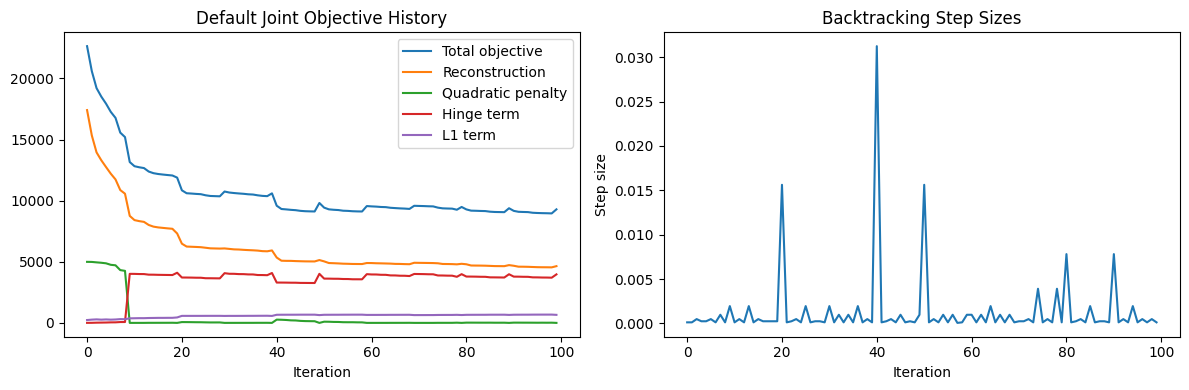

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(default_joint['result']['history']['objective'], label='Total objective')
axes[0].plot(default_joint['result']['history']['reconstruction'], label='Reconstruction')
axes[0].plot(default_joint['result']['history']['quadratic_penalty'], label='Quadratic penalty')
axes[0].plot(default_joint['result']['history']['hinge_term'], label='Hinge term')
axes[0].plot(default_joint['result']['history']['l1_term'], label='L1 term')
axes[0].set_title('Default Joint Objective History')
axes[0].set_xlabel('Iteration')
axes[0].legend()

axes[1].plot(default_joint['result']['history']['step_size'])
axes[1].set_title('Backtracking Step Sizes')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Step size')

plt.tight_layout()
plt.show()


## Stage 1: Coarse Search Over `rho` And `eta`

Purpose:

- identify a promising coupling/hinge region,
- avoid using only a single good-looking configuration,
- keep representation parameters fixed while diagnosing classifier coupling.

Fixed values in Stage 1:

- `dictionary_size = 64`
- `mu = 0.05`
- `gamma = 0.1`
- `max_iter = 100`

Coarse Stage 1 grid:

- `rho in {1, 5, 10, 20, 50}`
- `eta in {10, 20, 50, 80, 100}`

Run this first with a single seed for pruning.


In [ ]:
stage1_hyper = deepcopy(base_hyper)
stage1_hyper.dictionary_size = 64
stage1_hyper.mu = 0.05
stage1_hyper.gamma = 0.1
stage1_hyper.max_iter = 100

stage1_seed1_rows = scan_joint_grid(
    stage1_hyper,
    {
        'rho': [1.0, 5.0, 10.0, 20.0, 50.0],
        'eta': [10.0, 20.0, 50.0, 80.0, 100.0],
    },
    seeds=[7],
)

stage1_seed1_agg = aggregate_scan_rows(
    stage1_seed1_rows,
    group_keys=['dictionary_size', 'mu', 'rho', 'eta', 'gamma', 'max_iter'],
)
print_top_aggregates(stage1_seed1_agg, top_k=10)


## Stage 1B: Multi-Seed Recheck Of Best `rho/eta` Region

Take the best few Stage 1 candidates and re-check them with multiple seeds.
This is required because a single-seed winner may not be stable.

Recommended shortlist:

- the top 3 to 5 Stage 1 candidates
- seeds `{7, 13, 21}`


In [ ]:
stage1b_hyper = deepcopy(stage1_hyper)

stage1b_rows = scan_joint_grid(
    stage1b_hyper,
    {
        'rho': [5.0, 10.0, 20.0],
        'eta': [20.0, 50.0, 80.0, 100.0],
    },
    seeds=[7, 13, 21],
)

stage1b_agg = aggregate_scan_rows(
    stage1b_rows,
    group_keys=['dictionary_size', 'mu', 'rho', 'eta', 'gamma', 'max_iter'],
)
print_top_aggregates(stage1b_agg, top_k=10)


## Stage 1 Selection Note

Choose one `(rho, eta)` pair from the multi-seed Stage 1B table, not from the
single-seed table.


In [ ]:
best_stage1 = {
    'rho': 10.0,
    'eta': 10.0,
}
print(best_stage1)


## Stage 2: Local Refinement For Representation Capacity And Sparsity

Purpose:

- reduce overfitting risk,
- recover meaningful sparsity,
- test whether the joint model is using too much code capacity.

This stage is particularly important because earlier joint runs achieved very
high training accuracy with almost no sparsity while remaining weak on test.

Fixed values in Stage 2:

- `rho = best_stage1['rho']`
- `eta = best_stage1['eta']`
- `gamma = 0.1`
- `max_iter = 100`

Suggested Stage 2 grid:

- `dictionary_size in {48, 64, 80}`
- `mu in {0.08, 0.1, 0.12, 0.15}`

Use multiple seeds already in this stage.

This is a local refinement step centered on the current best Stage 2 region,
not a broad global sweep.


In [ ]:
stage2_hyper = deepcopy(base_hyper)
stage2_hyper.rho = best_stage1['rho']
stage2_hyper.eta = best_stage1['eta']
stage2_hyper.gamma = 0.1
stage2_hyper.max_iter = 100

stage2_rows = scan_joint_grid(
    stage2_hyper,
    {
        'dictionary_size': [48, 64, 80],
        'mu': [0.08, 0.1, 0.12, 0.15],
    },
    seeds=[7, 13, 21],
)

stage2_agg = aggregate_scan_rows(
    stage2_rows,
    group_keys=['dictionary_size', 'mu', 'rho', 'eta', 'gamma', 'max_iter'],
)
print_top_aggregates(stage2_agg, top_k=12)


## Stage 2 Selection Note

Choose one `(dictionary_size, mu)` pair from the Stage 2 multi-seed table.
When validation accuracy is nearly tied, prefer:

- smaller train-validation gap,
- stronger sparsity,
- lower validation reconstruction error.


In [ ]:
best_stage2 = {
    'dictionary_size': 48,
    'mu': 0.15,
}
print(best_stage2)


## Stage 3: Classifier Regularization And Optimization Budget

Purpose:

- refine classifier generalization with `gamma`,
- test whether the joint solver still needs more optimization budget.

Fixed values in Stage 3:

- `rho = best_stage1['rho']`
- `eta = best_stage1['eta']`
- `dictionary_size = best_stage2['dictionary_size']`
- `mu = best_stage2['mu']`

Suggested Stage 3 grid:

- `gamma in {0.01, 0.05, 0.1, 0.5, 1.0}`
- `max_iter in {100, 200, 400}`

Using `max_iter` here is justified because many runs terminate with
`max_iter_reached`, so optimization budget may still affect final validation
performance.


In [ ]:
stage3_hyper = deepcopy(base_hyper)
stage3_hyper.rho = best_stage1['rho']
stage3_hyper.eta = best_stage1['eta']
stage3_hyper.dictionary_size = best_stage2['dictionary_size']
stage3_hyper.mu = best_stage2['mu']

stage3_rows = scan_joint_grid(
    stage3_hyper,
    {
        'gamma': [0.01, 0.05, 0.1, 0.5, 1.0],
        'max_iter': [100, 200, 400],
    },
    seeds=[7, 13, 21],
)

stage3_agg = aggregate_scan_rows(
    stage3_rows,
    group_keys=['dictionary_size', 'mu', 'rho', 'eta', 'gamma', 'max_iter'],
)
print_top_aggregates(stage3_agg, top_k=12)


## Stage 3 Selection Note

Select the final validation winner here. This should be the configuration that
is transferred into the final results notebook.


In [ ]:
best_joint_config = {
    'dictionary_size': best_stage2['dictionary_size'],
    'mu': best_stage2['mu'],
    'rho': best_stage1['rho'],
    'eta': best_stage1['eta'],
    'gamma': 0.1,
    'max_iter': 100,
}
print(best_joint_config)


## Stage 4: Final Multi-Seed Verification

This is the last selection check before final reporting.

Recommended seeds:

- `{7, 13, 21, 42, 84}` for a stronger final estimate.

Only after inspecting this table should the final joint configuration be copied
into the results notebook.


In [ ]:
final_hyper = deepcopy(base_hyper)
for key, value in best_joint_config.items():
    setattr(final_hyper, key, value)

final_rows = []
for seed in [7, 13, 21, 42, 84]:
    trained = train_joint_once(final_hyper, seed=seed, evaluate_test=True)
    final_rows.append({
        'seed': seed,
        'train_accuracy': trained['train_metrics']['accuracy'],
        'val_accuracy': trained['val_metrics']['accuracy'],
        'test_accuracy': trained['test_metrics']['accuracy'],
        'train_code_sparsity': trained['train_metrics']['code_sparsity'],
        'val_code_sparsity': trained['val_metrics']['code_sparsity'],
        'val_reconstruction_error': trained['val_metrics']['reconstruction_error'],
        'status': trained['result']['status'],
    })

for row in final_rows:
    print(row)


In [ ]:
val_accs = np.array([row['val_accuracy'] for row in final_rows], dtype=np.float64)
test_accs = np.array([row['test_accuracy'] for row in final_rows], dtype=np.float64)
train_accs = np.array([row['train_accuracy'] for row in final_rows], dtype=np.float64)

print('train accuracy mean/std:', float(train_accs.mean()), float(train_accs.std()))
print('val accuracy mean/std:', float(val_accs.mean()), float(val_accs.std()))
print('test accuracy mean/std:', float(test_accs.mean()), float(test_accs.std()))


## Final Configuration To Transfer

Copy the configuration below into `04_results_analysis.ipynb` only after the
Stage 4 multi-seed verification looks satisfactory.


In [ ]:
print('Final joint configuration for results notebook:')
print(best_joint_config)
